In [162]:
import pandas as pd

import seaborn as sns

import pandas as pd

import numpy as np

# import matplotlib.pyplot as plt

import warnings

import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib

warnings.filterwarnings("ignore")

df = pd.read_csv("../data/pricing_data.csv")



In [163]:
X = df.drop(columns=["price", "service", "order_placed", "task_accepted", "task_completed"])  # Keep only useful features
y = df["price"]

# print (X.dtypes)

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [167]:
# Define hyperparameters
params = {"objective": "reg:squarederror",
    "eval_metric":["rmse", "mae"],
    "max_depth": 4,
    "min_child_weight": 3,
    "gamma": 0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eta": 0.05,
    "lambda": 0.5,
    "alpha": 1,
    "tree_method": "hist",  
    "seed": 42
    }
# params = {
#     'max_depth': [4, 5, 6],
#     'learning_rate': [0.03, 0.05, 0.1],
#     'n_estimators': [200, 500, 800],
#     'subsample': [0,7, 0.8 ],
#     'colsample_bytree': [0.8, 1.0],
#     'reg_lambda': [0,25, 0.5, 1],
#     'reg_alpha': [0, 0.5, 1]
# }

# xgb_model = XGBRegressor(objective="reg:squarederror", random_state=42)
# grid = GridSearchCV(estimator=xgb_model, param_grid=params, scoring='neg_root_mean_squared_error', cv=3, verbose=0)
# grid.fit(X_train, y_train)

# print("Best Params:", grid.best_params_)
# print("Best Score: (negative RMSE)", grid.best_score_)

n=10000

evals = [(dtrain_reg, "train"), (dtest_reg, "validation")]

eval_result = {}

# model = XGBRegressor(**grid.best_params_)
# model.fit(
#     X_train, y_train,
#     eval_set=[(X_train, y_train), (X_test, y_test)],
#     # early_stopping_rounds=50,
#     verbose=500
# )

model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
    evals=evals,
    evals_result=eval_result,
    verbose_eval=500,
    early_stopping_rounds=50
)

y_pred = model.predict(dtest_reg)
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

print(f"RMSE of the base model: {rmse:.3f}")


[0]	train-rmse:103.52563	train-mae:76.79676	validation-rmse:102.94628	validation-mae:77.68683
[500]	train-rmse:7.33703	train-mae:5.32638	validation-rmse:10.95229	validation-mae:6.88601
[787]	train-rmse:6.60449	train-mae:4.84348	validation-rmse:10.81621	validation-mae:6.83139
RMSE of the base model: 10.816


In [168]:
results = xgb.cv(
   params, dtrain_reg,
   num_boost_round=n,
   nfold=5,
   early_stopping_rounds=20
)

# results = xgb.cv(
#     params=grid.best_params_,            
#     dtrain=dtrain_reg,        
#     num_boost_round=10000,     
#     nfold=5,                  
#     early_stopping_rounds=50, 
#     metrics= ["rmse", "mae"],           
#     seed=42,
#     as_pandas=True            
# )

results.tail()

,train-rmse-mean,train-rmse-std,train-mae-mean,train-mae-std,test-rmse-mean,test-rmse-std,test-mae-mean,test-mae-std
931,6.008212,0.044473,4.447162,0.033431,10.234370,0.379016,6.835228,0.172864
932,6.006404,0.044274,4.445926,0.033200,10.233846,0.379523,6.834855,0.173479
933,6.004089,0.044282,4.443970,0.032991,10.233204,0.380195,6.834269,0.174629
934,6.002433,0.044526,4.442647,0.033314,10.233040,0.379949,6.834162,0.174834
935,6.000027,0.044168,4.440830,0.033039,10.231533,0.379936,6.833535,0.174435


In [169]:
best_rmse = results['test-rmse-mean'].min()
best_mae = results['test-mae-mean'].min()

print(f"Best RMSE of the base model: {best_rmse:.3f}")
print(f"Best MAE of the base model: {best_mae:.3f}")

Best RMSE of the base model: 10.232
Best MAE of the base model: 6.834


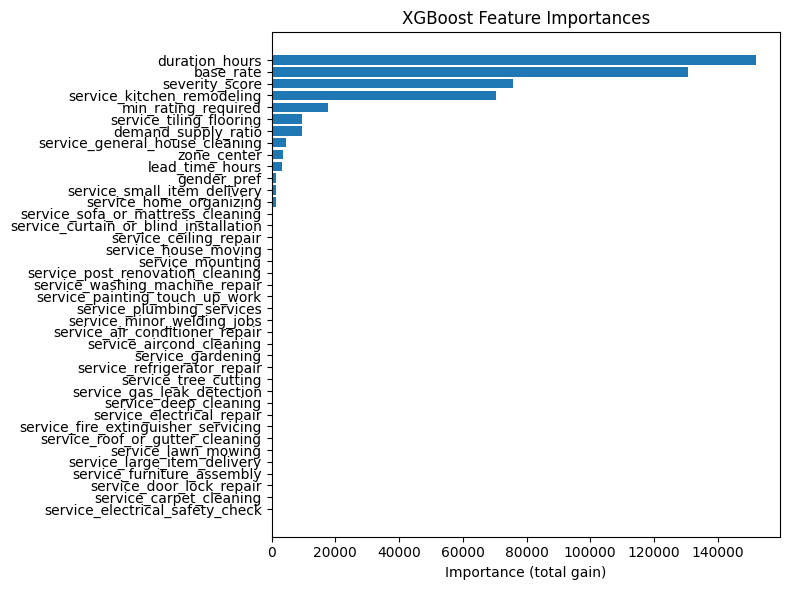

In [171]:
# features = X_train.columns
# importances = model.feature_importances_

# sns.barplot(x=importances, y=features)
# plt.title("Feature Importance")
# plt.show

# 1. Get the raw importance scores (choose 'gain', 'weight', or 'cover')
#    'weight' counts how many times a feature is used in splits
#    'gain' sums the improvement in loss brought by splits on that feature
#    'cover' sums the number of samples affected by splits on that feature
importance_dict = model.get_score(importance_type='gain')

# 2. Convert to a DataFrame for easy plotting, ensuring every feature appears
features = X_train.columns.tolist()
importances = [importance_dict.get(f, 0.0) for f in features]
df_imp = pd.DataFrame({'feature': features, 'importance': importances})

# 3. Sort by importance and plot
df_imp = df_imp.sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(df_imp['feature'], df_imp['importance'])
plt.xlabel('Importance (total gain)')
plt.title('XGBoost Feature Importances')
plt.tight_layout()
plt.show()

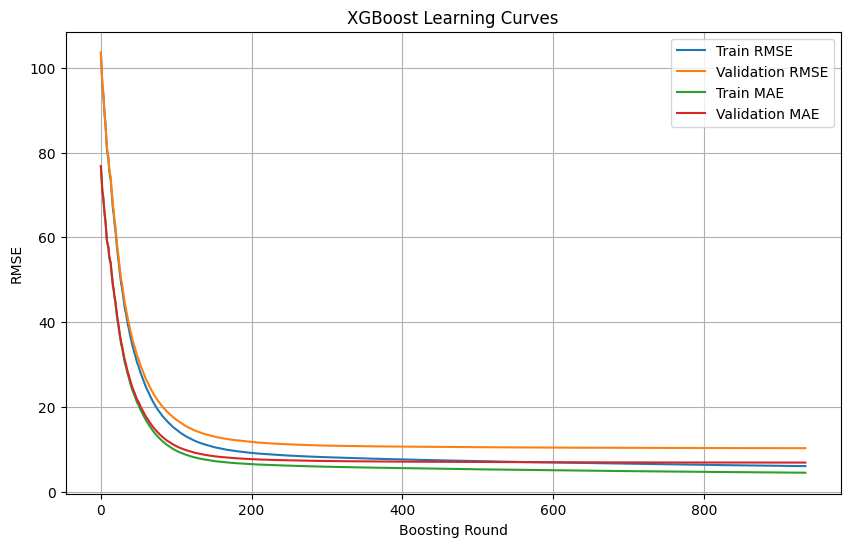

In [172]:
# Plot learning curves
# epochs = len(eval_result["train"]["rmse"])
# x_axis = range(epochs)

# plt.figure(figsize=(10,6))
# plt.plot(x_axis, eval_result["train"]["rmse"], label='Train RMSE')
# plt.plot(x_axis, eval_result["validation"]["rmse"], label='Validation RMSE')
# plt.plot(x_axis, eval_result["train"]["mae"], label='Train MAE', linestyle='--')
# plt.plot(x_axis, eval_result["validation"]["mae"], label='Validation MAE', linestyle='--')

# plt.title("XGBoost Learning Curves")
# plt.xlabel("Boosting Round")
# plt.ylabel("Error")
# plt.legend()
# plt.grid(True)
# plt.show()

# Number of boosting rounds
epochs = len(results)
x_axis = range(epochs)

# Plot RMSE Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['train-rmse-mean'], label='Train RMSE')
plt.plot(x_axis, results['test-rmse-mean'], label='Validation RMSE')
plt.plot(x_axis, results['train-mae-mean'], label='Train MAE')
plt.plot(x_axis, results['test-mae-mean'], label='Validation MAE')

plt.title("XGBoost Learning Curves")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True)
plt.show()

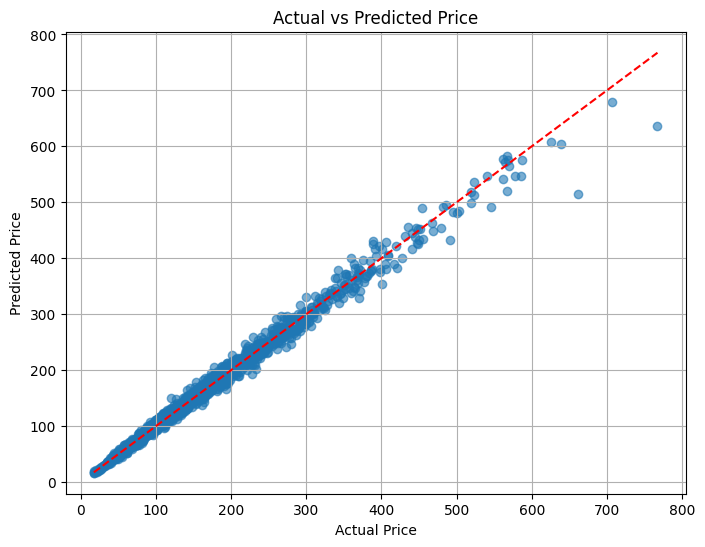

In [173]:
# How close is the prediction price and the actual price
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid(True)
plt.show()

In [174]:
joblib.dump(model, 'xgboost_model.pkl')

['xgboost_model.pkl']